### <div style="background-color:blue; color:white; padding:10px;">Load all required files</div>

In [61]:
# =========================
# IMPORTS
# =========================
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp

from sklearn.manifold import TSNE
import matplotlib.patheffects as path_effects

# =========================
# DEVICE
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# LOAD DATA
# =========================
FEATURES_CSV = "../Features/EPIC/P01_04_fused_features.csv"
LABELS_CSV = "../Labels/EPIC/P01_04_labels.csv"

features_df = pd.read_csv(FEATURES_CSV)
labels_df = pd.read_csv(LABELS_CSV)

features = features_df.drop(columns=["frame_id"]).values.astype(np.float32)
labels = labels_df.drop(columns=["frame_id"]).values.astype(np.float32)

X = torch.from_numpy(features).to(DEVICE)

T, FEATURE_DIM = features.shape
NUM_CLASSES = labels.shape[1]

# =========================
# MODEL (WITH INTERMEDIATE FEATURES)
# =========================
class Classifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        f1 = self.relu(self.bn1(self.fc1(x)))
        f1 = self.dropout(f1)

        f2 = self.relu(self.bn2(self.fc2(f1)))
        f2 = self.dropout(f2)

        out = self.fc3(f2)

        return out, f1, f2

# =========================
# LOAD MODEL
# =========================
model = Classifier(FEATURE_DIM, NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load("../Model/EPIC/P01_04_model.pt", map_location=DEVICE), strict=False)
model.eval()

# =========================
# LOAD GRAPH
# =========================
GRAPH_PATH = "../Graph/EPIC/P01_04_transition_matrix.npz"
P_sparse = sp.load_npz(GRAPH_PATH)
P = P_sparse.toarray().astype(np.float32)
P_tensor = torch.from_numpy(P).to(DEVICE)

# =========================
# RANDOM WALK
# =========================
def residual_random_walk(logits, P, alpha=0.5, steps=5):
    Y = torch.sigmoid(logits)
    confidence = torch.abs(Y - 0.5) * 2
    uncertainty = 1 - confidence

    for _ in range(steps):
        Y = Y + alpha * uncertainty * (torch.matmul(P, Y) - Y)

    return Y

# =========================
# FORWARD PASS
# =========================
with torch.no_grad():
    logits, feat_512, feat_256 = model(X)

feat_input = features
feat_512 = feat_512.cpu().numpy()

scores_before = torch.sigmoid(logits).cpu().numpy()
scores_after = residual_random_walk(logits, P_tensor).cpu().numpy()

cluster_labels = np.argmax(labels, axis=1)

C:\Users\PAWANESH\AppData\Local\Temp\ipykernel_26092\2704820090.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../Model/EPIC/P01_04_m

In [105]:
scores_after

array([[0.5195935 , 0.5063136 , 0.51176065, ..., 0.48872015, 0.51364285,
        0.51351315],
       [0.51949084, 0.506123  , 0.51193976, ..., 0.4886934 , 0.51364595,
        0.5135298 ],
       [0.51956105, 0.5062347 , 0.51190513, ..., 0.48870042, 0.5136365 ,
        0.5135313 ],
       ...,
       [0.52467155, 0.5045312 , 0.513527  , ..., 0.4923724 , 0.51233214,
        0.51296866],
       [0.5246306 , 0.50459975, 0.5135225 , ..., 0.49232167, 0.5124492 ,
        0.51292586],
       [0.5194678 , 0.50607866, 0.5119294 , ..., 0.4888444 , 0.5135904 ,
        0.5133881 ]], dtype=float32)

In [62]:
# =========================
# TSNE (CONSISTENT)
# =========================
combined_feat = np.concatenate([feat_input, feat_512], axis=0)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
combined_2d = tsne.fit_transform(combined_feat)
feat_input_2d = combined_2d[:T]
feat_512_2d = combined_2d[T:]

In [106]:
# =========================
# DIMPLOT STYLE FUNCTION
# =========================
def dimplot_style(ax, feat_2d, cluster_labels, title, target_classes):
    colors = np.where(np.isin(cluster_labels, target_classes),
                  cluster_labels,
                  -1)
    ax.scatter(feat_2d[:,0], feat_2d[:,1],
           c=colors, cmap='Accent', s=0.5, alpha=0.8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    # ONLY target classes
    for cls in target_classes:
        idx = cluster_labels == cls
        # Skip if class not present
        if np.sum(idx) == 0:
            continue
        x_mean = feat_2d[idx, 0].mean()
        y_mean = feat_2d[idx, 1].mean()
        txt = ax.text(
            x_mean, y_mean, str(cls),
            fontsize=12, weight='bold',
            ha='center', va='center',
            color='black'
        )
        txt.set_path_effects([
            path_effects.Stroke(linewidth=3, foreground='white'),
            path_effects.Normal()
        ])
    ax.set_title(title)

# =========================
# TARGET CLASSES
# =========================
target_classes = [0, 1, 4, 5, 6, 10]

# =========================
# STEM (TARGET ONLY)
# =========================
def plot_stem_target_only(ax, scores, classes, title, top_k=15):
    for c in classes:
        y = scores[:, c]
        y = (y - y.min()) / (y.max() - y.min() + 1e-8)
        peak_indices = np.argsort(y)[-top_k:]
        for idx in peak_indices:
            ax.vlines(idx, 0, y[idx], color='green', linewidth=1)
        best_idx = np.argmax(y)
        ax.scatter(best_idx, y[best_idx], color='green', s=100, marker='*')
        ax.text(best_idx, y[best_idx], str(c), fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([0, 0.5, 1])
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


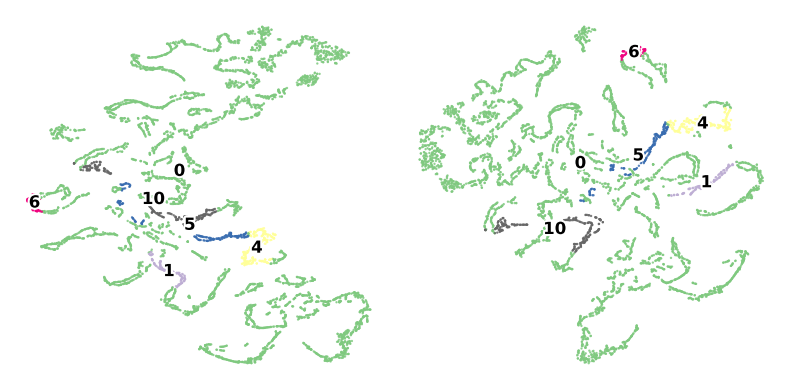

In [111]:
# =========================
# ROW 1: FEATURE VISUALIZATION
# =========================
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# DimPlot style (target-only labels)
dimplot_style(axes[0], feat_input_2d, cluster_labels, "", target_classes)
dimplot_style(axes[1], feat_512_2d, cluster_labels, "", target_classes)

plt.tight_layout()

# =========================
# SAVE ROW 1
# =========================
plt.savefig("feature_changes.png", format='png', dpi=1000, bbox_inches='tight')
plt.savefig("feature_changes.pdf", bbox_inches='tight')

plt.show()

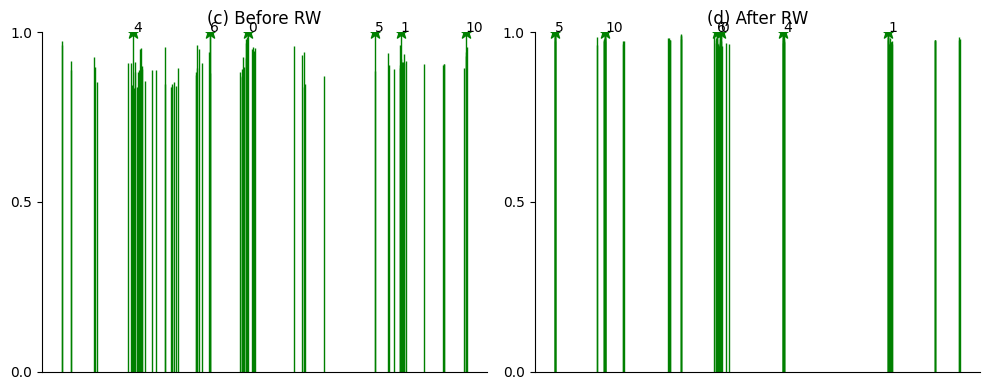

In [108]:
# =========================
# ROW 2: SCORE VISUALIZATION
# =========================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Target-only stem plots
plot_stem_target_only(axes[0], scores_before, target_classes, "(c) Before RW")
plot_stem_target_only(axes[1], scores_after, target_classes, "(d) After RW")

plt.tight_layout()

# =========================
# SAVE ROW 2
# =========================
# plt.savefig("row2_scores.eps", format='eps', dpi=600, bbox_inches='tight')
# plt.savefig("row2_scores.pdf", bbox_inches='tight')

plt.show()

In [9]:
# ============================================================
# FULL FIXED CODE — Correct model loading + Reference style plot
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.sparse as sp
from sklearn.manifold import TSNE
import matplotlib.patheffects as path_effects
import os

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ============================================================
# PATHS
# ============================================================
FEATURES_CSV = "../Features/ADL/P_11_rgb_features.csv"
LABELS_CSV   = "../Labels/ADL/P_11_labeled.csv"
GRAPH_PATH   = "../Graph/ADL/P_11_transition_matrix.npz"
MODEL_PATH   = "../Model/ADL/P_11_model.pt"
SAVE_DIR     = "../Qualitative/ADL/"
os.makedirs(SAVE_DIR, exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================
features_df  = pd.read_csv(FEATURES_CSV)
labels_df    = pd.read_csv(LABELS_CSV)
features     = features_df.drop(
                   columns=["frame_id"]).values.astype(np.float32)
labels       = labels_df.drop(
                   columns=["frame_id"]).values.astype(np.float32)

X            = torch.from_numpy(features).to(DEVICE)
T, FEATURE_DIM = features.shape
NUM_CLASSES  = labels.shape[1]
print(f"Features: {features.shape}, Labels: {labels.shape}")

# ============================================================
# MODEL — matches saved net.* architecture exactly
# ============================================================
class Classifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),   # net.0
            nn.BatchNorm1d(512),          # net.1
            nn.ReLU(),                    # net.2
            nn.Dropout(0.3),              # net.3
            nn.Linear(512, 256),          # net.4
            nn.BatchNorm1d(256),          # net.5
            nn.ReLU(),                    # net.6
            nn.Dropout(0.3),              # net.7
            nn.Linear(256, num_classes)   # net.8
        )

    def forward(self, x):
        # Extract intermediate features manually
        f1 = self.net[0](x)              # Linear 512
        f1 = self.net[1](f1)             # BN
        f1 = self.net[2](f1)             # ReLU
        f1 = self.net[3](f1)             # Dropout

        f2 = self.net[4](f1)             # Linear 256
        f2 = self.net[5](f2)             # BN
        f2 = self.net[6](f2)             # ReLU
        f2 = self.net[7](f2)             # Dropout

        out = self.net[8](f2)            # Output
        return out, f1, f2

# ============================================================
# LOAD MODEL — strict=True now works
# ============================================================
model      = Classifier(FEATURE_DIM, NUM_CLASSES).to(DEVICE)
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)

print("\nSaved model keys:")
for k in list(state_dict.keys()):
    print(f"  {k}")

model.load_state_dict(state_dict, strict=True)
print("\nModel loaded successfully with strict=True")
model.eval()

# ============================================================
# LOAD GRAPH
# ============================================================
P_sparse   = sp.load_npz(GRAPH_PATH)
P          = P_sparse.toarray().astype(np.float32)
P_tensor   = torch.from_numpy(P).to(DEVICE)

# ============================================================
# CARRW
# ============================================================
def residual_random_walk(logits, P, alpha=0.5, steps=5):
    Y           = torch.sigmoid(logits)
    confidence  = torch.abs(Y - 0.5) * 2
    uncertainty = 1 - confidence
    for _ in range(steps):
        Y = Y + alpha * uncertainty * (
            torch.matmul(P, Y) - Y)
    return Y

# ============================================================
# FORWARD PASS
# ============================================================
with torch.no_grad():
    logits, feat_512, feat_256 = model(X)

feat_input    = features
feat_learned  = feat_512.cpu().numpy()
scores_before = torch.sigmoid(logits).cpu().numpy()
scores_after  = residual_random_walk(
    logits, P_tensor).cpu().numpy()

cluster_labels = np.argmax(labels, axis=1)

# ============================================================
# TARGET CLASSES — top 6 most active
# ============================================================
active_counts  = labels.sum(axis=0)
top6_classes   = list(np.argsort(active_counts)[-6:])
target_classes = top6_classes
print(f"\nTarget classes: {target_classes}")


Device: cuda
Features: (14775, 512), Labels: (14775, 32)

Saved model keys:
  net.0.weight
  net.0.bias
  net.1.weight
  net.1.bias
  net.1.running_mean
  net.1.running_var
  net.1.num_batches_tracked
  net.4.weight
  net.4.bias
  net.5.weight
  net.5.bias
  net.5.running_mean
  net.5.running_var
  net.5.num_batches_tracked
  net.8.weight
  net.8.bias

Model loaded successfully with strict=True


C:\Users\PAWANESH\AppData\Local\Temp\ipykernel_24684\2402871943.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(MODEL_PATH, map_location=DEVICE)


Target classes: [30, 5, 31, 14, 12, 23]



Running t-SNE...


C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE done.


C:\Users\PAWANESH\AppData\Local\Temp\ipykernel_24684\4032842379.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(target_classes))


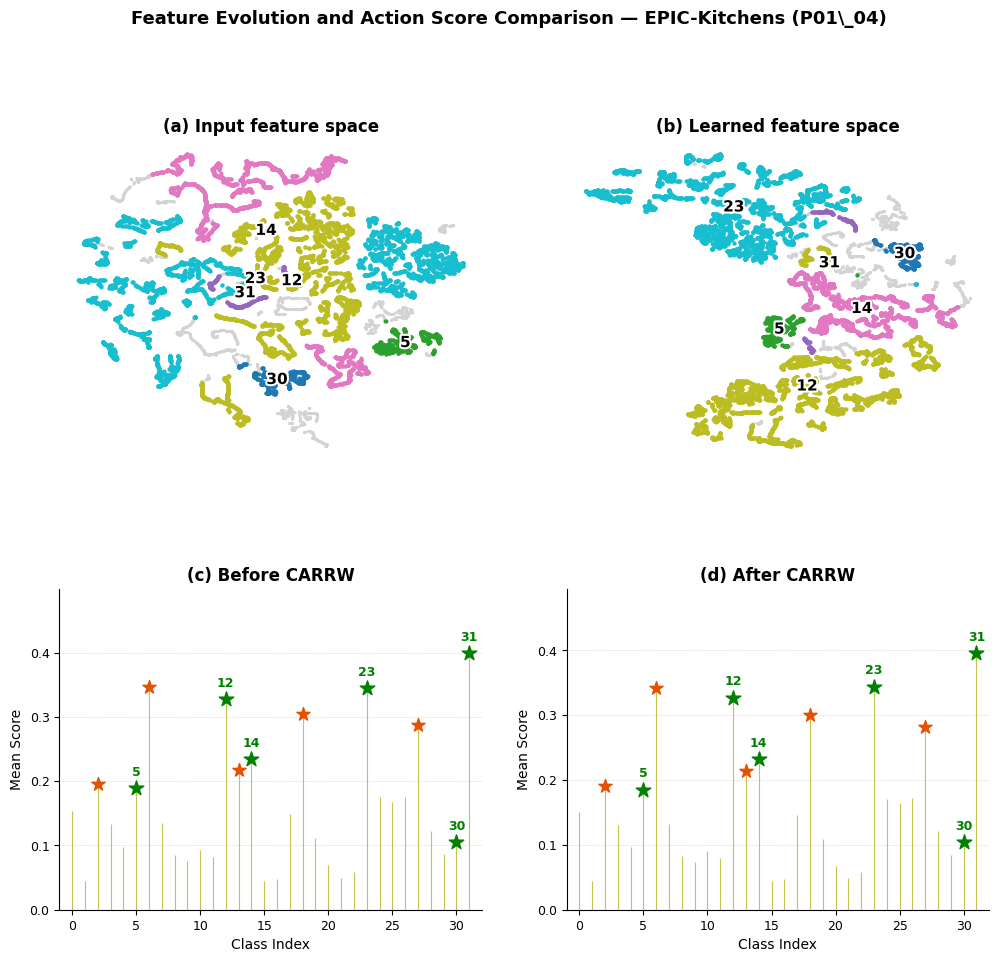

Saved.


In [10]:
# ============================================================
# t-SNE
# ============================================================
print("\nRunning t-SNE...")
combined_feat   = np.concatenate(
    [feat_input, feat_learned], axis=0)
tsne            = TSNE(
    n_components=2, perplexity=30,
    random_state=42, n_iter=1000)
combined_2d     = tsne.fit_transform(combined_feat)
feat_input_2d   = combined_2d[:T]
feat_learned_2d = combined_2d[T:]
print("t-SNE done.")

# ============================================================
# HELPER — DimPlot style
# ============================================================
def dimplot_style(ax, feat_2d, cluster_labels,
                  title, target_classes):
    ax.scatter(
        feat_2d[:, 0], feat_2d[:, 1],
        c="lightgray", s=1.5, alpha=0.5, zorder=1
    )
    cmap = plt.cm.get_cmap("tab10", len(target_classes))
    for idx, cls in enumerate(target_classes):
        mask = cluster_labels == cls
        if mask.sum() == 0:
            continue
        ax.scatter(
            feat_2d[mask, 0], feat_2d[mask, 1],
            c=[cmap(idx)], s=4, alpha=0.85, zorder=2
        )
        xm  = feat_2d[mask, 0].mean()
        ym  = feat_2d[mask, 1].mean()
        txt = ax.text(
            xm, ym, str(cls),
            fontsize=11, weight="bold",
            ha="center", va="center",
            color="black", zorder=3
        )
        txt.set_path_effects([
            path_effects.Stroke(
                linewidth=3, foreground="white"),
            path_effects.Normal()
        ])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    ax.set_title(title, fontsize=12,
                 fontweight="bold", pad=6)

# ============================================================
# HELPER — Reference style spike plot
# X-axis = class index (0 to NUM_CLASSES-1)
# Y-axis = mean score across all frames
# Green star = target class peaks
# Red star   = non-target peaks (top-5 highest non-target)
# Yellow lines = all class scores
# ============================================================
def plot_spike_reference(ax, scores, target_classes,
                         title, num_classes):
    # Mean score per class across all frames
    mean_scores = scores.mean(axis=0)  # (NUM_CLASSES,)
    x           = np.arange(num_classes)

    # Draw all spikes in olive/yellow color
    for i in range(num_classes):
        ax.vlines(
            i, 0, mean_scores[i],
            color="#b5b520",
            linewidth=0.8, alpha=0.8
        )

    # Green stars — target classes
    for cls in target_classes:
        ax.scatter(
            cls, mean_scores[cls],
            color="green", s=120,
            marker="*", zorder=5
        )
        ax.text(
            cls, mean_scores[cls] + 0.015,
            str(cls),
            fontsize=9, color="green",
            fontweight="bold",
            ha="center", va="bottom"
        )

    # Red/orange stars — top-5 non-target peaks
    non_target  = [i for i in range(num_classes)
                   if i not in target_classes]
    top5_non    = sorted(
        non_target,
        key=lambda i: mean_scores[i],
        reverse=True
    )[:5]
    for cls in top5_non:
        ax.scatter(
            cls, mean_scores[cls],
            color="#E65100", s=100,
            marker="*", zorder=5
        )

    ax.set_xlim(-1, num_classes)
    ax.set_ylim(0, mean_scores.max() * 1.25)
    ax.set_xlabel("Class Index", fontsize=10)
    ax.set_ylabel("Mean Score", fontsize=10)
    ax.set_title(title, fontsize=12,
                 fontweight="bold", pad=6)
    ax.grid(axis="y", linestyle="--",
            alpha=0.4, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis='both', labelsize=9)

# ============================================================
# COMBINED FIGURE
# ============================================================
fig = plt.figure(figsize=(12, 10))
fig.patch.set_facecolor("white")

gs  = gridspec.GridSpec(
    2, 2, figure=fig,
    hspace=0.40, wspace=0.20
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Row 1 — t-SNE
dimplot_style(
    ax1, feat_input_2d, cluster_labels,
    "(a) Input feature space", target_classes
)
dimplot_style(
    ax2, feat_learned_2d, cluster_labels,
    "(b) Learned feature space", target_classes
)

# Row 2 — Spike plots
plot_spike_reference(
    ax3, scores_before, target_classes,
    "(c) Before CARRW", NUM_CLASSES
)
plot_spike_reference(
    ax4, scores_after, target_classes,
    "(d) After CARRW", NUM_CLASSES
)

plt.suptitle(
    "Feature Evolution and Action Score Comparison "
    "— EPIC-Kitchens (P01\\_04)",
    fontsize=13, fontweight="bold", y=1.01
)

# ============================================================
# SAVE
# ============================================================
# plt.savefig(
#     f"{SAVE_DIR}P01_04_Before_After.pdf",
#     bbox_inches="tight", facecolor="white"
# )
# plt.savefig(
#     f"{SAVE_DIR}P01_04_Before_After.eps",
#     format="eps", dpi=1000,
#     bbox_inches="tight", facecolor="white"
# )
plt.show()
print("Saved.")

Device: cuda
Features : (6180, 512)
Labels   : (6180, 29)

Saved model keys:
  net.0.weight
  net.0.bias
  net.1.weight
  net.1.bias
  net.1.running_mean
  net.1.running_var
  net.1.num_batches_tracked
  net.4.weight
  net.4.bias
  net.5.weight
  net.5.bias
  net.5.running_mean
  net.5.running_var
  net.5.num_batches_tracked
  net.8.weight
  net.8.bias

Model loaded successfully.


C:\Users\PAWANESH\AppData\Local\Temp\ipykernel_24684\924736773.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(MODEL_PATH, map_location=DEVICE)


Transition matrix: torch.Size([6180, 6180])

Active at frame 4217 : [17, 18]
Top 6 overall             : [10, 20, 9, 0, 25, 14]
Final target classes      : [0, 9, 10, 14, 17, 18, 20, 25]

Running t-SNE...


C:\Users\PAWANESH\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE done.

Scores at frame 4217:
  Before CARRW — target classes [17, 18]: [0.99311125 0.9958181 ]
  After  CARRW — target classes [17, 18]: [0.9932451 0.9958248]

Difference (After - Before):
  Max gain  : 0.1468 at class 7
  Max drop  : -0.0943 at class 27


C:\Users\PAWANESH\AppData\Local\Temp\ipykernel_24684\924736773.py:174: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10",


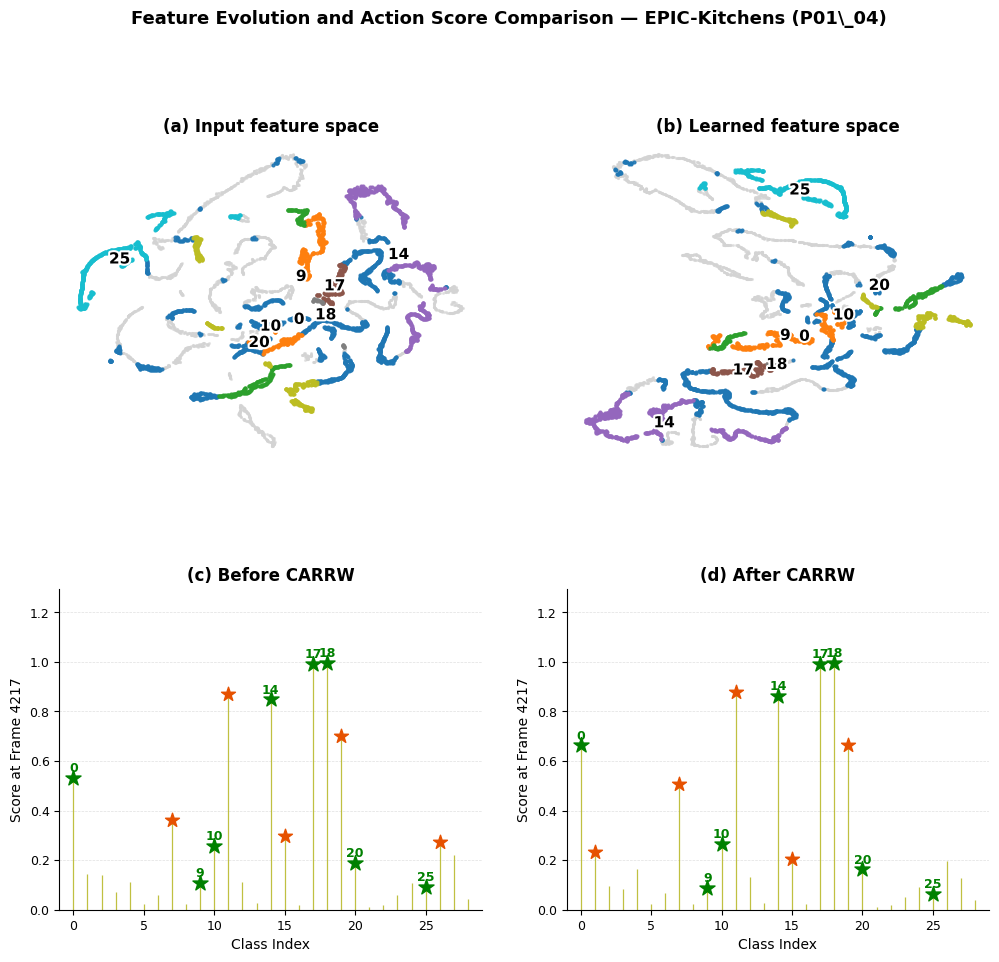


Saved.


In [11]:
# ============================================================
# FULL UPDATED CODE — Feature Visualization + Score Comparison
# Fixed: model loading + spike plot at best multi-action frame
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.sparse as sp
from sklearn.manifold import TSNE
import matplotlib.patheffects as path_effects
import os

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ============================================================
# PATHS
# ============================================================
FEATURES_CSV = "../Features/EPIC/P01_04_vgg_fused_features.csv"
LABELS_CSV   = "../Labels/EPIC/P01_04_vgg_fused_labeled.csv"
GRAPH_PATH   = "../Graph/EPIC/P01_04_vgg_fused_transition_matrix.npz"
MODEL_PATH   = "../Model/EPIC/P01_04_vgg_fused_model.pt"
SAVE_DIR     = "../Qualitative/EPIC/"
os.makedirs(SAVE_DIR, exist_ok=True)

# Best multi-action frame — rinse sink + rinse hand
BEST_FRAME   = 4217

# ============================================================
# LOAD DATA
# ============================================================
features_df  = pd.read_csv(FEATURES_CSV)
labels_df    = pd.read_csv(LABELS_CSV)
features     = features_df.drop(
                   columns=["frame_id"]).values.astype(np.float32)
labels       = labels_df.drop(
                   columns=["frame_id"]).values.astype(np.float32)

X            = torch.from_numpy(features).to(DEVICE)
T, FEATURE_DIM = features.shape
NUM_CLASSES  = labels.shape[1]
print(f"Features : {features.shape}")
print(f"Labels   : {labels.shape}")

# ============================================================
# MODEL — matches saved net.* architecture exactly
# ============================================================
class Classifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),   # net.0
            nn.BatchNorm1d(512),          # net.1
            nn.ReLU(),                    # net.2
            nn.Dropout(0.3),              # net.3
            nn.Linear(512, 256),          # net.4
            nn.BatchNorm1d(256),          # net.5
            nn.ReLU(),                    # net.6
            nn.Dropout(0.3),              # net.7
            nn.Linear(256, num_classes)   # net.8
        )

    def forward(self, x):
        # Extract intermediate features via indexing
        f1  = self.net[0](x)
        f1  = self.net[1](f1)
        f1  = self.net[2](f1)
        f1d = self.net[3](f1)

        f2  = self.net[4](f1d)
        f2  = self.net[5](f2)
        f2  = self.net[6](f2)
        f2d = self.net[7](f2)

        out = self.net[8](f2d)
        return out, f1, f2

# ============================================================
# LOAD MODEL
# ============================================================
model      = Classifier(FEATURE_DIM, NUM_CLASSES).to(DEVICE)
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)

print("\nSaved model keys:")
for k in list(state_dict.keys()):
    print(f"  {k}")

model.load_state_dict(state_dict, strict=True)
print("\nModel loaded successfully.")
model.eval()

# ============================================================
# LOAD GRAPH
# ============================================================
P_sparse   = sp.load_npz(GRAPH_PATH)
P          = P_sparse.toarray().astype(np.float32)
P_tensor   = torch.from_numpy(P).to(DEVICE)
print(f"Transition matrix: {P_tensor.shape}")

# ============================================================
# CARRW
# ============================================================
def residual_random_walk(logits, P, alpha=0.5, steps=5):
    Y           = torch.sigmoid(logits)
    confidence  = torch.abs(Y - 0.5) * 2
    uncertainty = 1 - confidence
    for _ in range(steps):
        Y = Y + alpha * uncertainty * (
            torch.matmul(P, Y) - Y)
    return Y

# ============================================================
# FORWARD PASS
# ============================================================
with torch.no_grad():
    logits, feat_512, feat_256 = model(X)

feat_input    = features
feat_learned  = feat_512.cpu().numpy()
scores_before = torch.sigmoid(logits).cpu().numpy()
scores_after  = residual_random_walk(
    logits, P_tensor).cpu().numpy()

cluster_labels = np.argmax(labels, axis=1)

# ============================================================
# TARGET CLASSES — active at best multi-action frame
# Also include top active classes overall
# ============================================================
# Classes active at best frame
active_at_best = np.where(
    labels[BEST_FRAME, :] == 1)[0].tolist()

# Top active classes overall
active_counts  = labels.sum(axis=0)
top6_overall   = list(np.argsort(active_counts)[-6:])

# Combine both — unique
target_classes = list(set(active_at_best + top6_overall))
print(f"\nActive at frame {BEST_FRAME} : {active_at_best}")
print(f"Top 6 overall             : {top6_overall}")
print(f"Final target classes      : {target_classes}")

# ============================================================
# t-SNE
# ============================================================
print("\nRunning t-SNE...")
combined_feat   = np.concatenate(
    [feat_input, feat_learned], axis=0)
tsne            = TSNE(
    n_components=2, perplexity=30,
    random_state=42, n_iter=1000)
combined_2d     = tsne.fit_transform(combined_feat)
feat_input_2d   = combined_2d[:T]
feat_learned_2d = combined_2d[T:]
print("t-SNE done.")

# ============================================================
# HELPER — DimPlot style t-SNE
# ============================================================
def dimplot_style(ax, feat_2d, cluster_labels,
                  title, target_classes):
    # Gray background
    ax.scatter(
        feat_2d[:, 0], feat_2d[:, 1],
        c="lightgray", s=1.5,
        alpha=0.5, zorder=1
    )
    # Colored target classes
    cmap = plt.cm.get_cmap("tab10",
                           len(target_classes))
    for idx, cls in enumerate(target_classes):
        mask = cluster_labels == cls
        if mask.sum() == 0:
            continue
        ax.scatter(
            feat_2d[mask, 0],
            feat_2d[mask, 1],
            c=[cmap(idx)], s=4,
            alpha=0.85, zorder=2
        )
        xm  = feat_2d[mask, 0].mean()
        ym  = feat_2d[mask, 1].mean()
        txt = ax.text(
            xm, ym, str(cls),
            fontsize=11, weight="bold",
            ha="center", va="center",
            color="black", zorder=3
        )
        txt.set_path_effects([
            path_effects.Stroke(
                linewidth=3,
                foreground="white"),
            path_effects.Normal()
        ])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    ax.set_title(
        title, fontsize=12,
        fontweight="bold", pad=6)

# ============================================================
# HELPER — Spike plot at best multi-action frame
# Green stars = target classes (should be boosted after CARRW)
# Red stars   = top-5 non-target peaks (should drop after CARRW)
# Yellow lines = all class scores
# ============================================================
def plot_spike_reference(ax, scores, target_classes,
                         title, num_classes,
                         frame_idx=None):
    if frame_idx is not None:
        # Score at specific frame
        frame_scores = scores[frame_idx, :]
        ylabel       = f"Score at Frame {frame_idx}"
    else:
        # Fallback to max score
        frame_scores = scores.max(axis=0)
        ylabel       = "Peak Score"

    # All spikes — olive yellow
    for i in range(num_classes):
        ax.vlines(
            i, 0, frame_scores[i],
            color="#b5b520",
            linewidth=0.9, alpha=0.85
        )

    # Green stars — target classes
    for cls in target_classes:
        if cls >= num_classes:
            continue
        ax.scatter(
            cls, frame_scores[cls],
            color="green", s=130,
            marker="*", zorder=5
        )
        ax.text(
            cls,
            frame_scores[cls] + 0.012,
            str(cls),
            fontsize=9, color="green",
            fontweight="bold",
            ha="center", va="bottom"
        )

    # Red stars — top-5 non-target highest peaks
    non_target  = [i for i in range(num_classes)
                   if i not in target_classes]
    top5_non    = sorted(
        non_target,
        key=lambda i: frame_scores[i],
        reverse=True
    )[:5]
    for cls in top5_non:
        ax.scatter(
            cls, frame_scores[cls],
            color="#E65100", s=110,
            marker="*", zorder=5
        )

    ax.set_xlim(-1, num_classes)
    ax.set_ylim(0, frame_scores.max() * 1.30)
    ax.set_xlabel("Class Index", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(
        title, fontsize=12,
        fontweight="bold", pad=6)
    ax.grid(axis="y", linestyle="--",
            alpha=0.4, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis='both', labelsize=9)

# ============================================================
# PRINT SCORES AT BEST FRAME FOR VERIFICATION
# ============================================================
print(f"\nScores at frame {BEST_FRAME}:")
print(f"  Before CARRW — "
      f"target classes {active_at_best}: "
      f"{scores_before[BEST_FRAME, active_at_best]}")
print(f"  After  CARRW — "
      f"target classes {active_at_best}: "
      f"{scores_after[BEST_FRAME, active_at_best]}")
print(f"\nDifference (After - Before):")
diff = scores_after[BEST_FRAME, :] - \
       scores_before[BEST_FRAME, :]
print(f"  Max gain  : {diff.max():.4f} "
      f"at class {diff.argmax()}")
print(f"  Max drop  : {diff.min():.4f} "
      f"at class {diff.argmin()}")

# ============================================================
# COMBINED FIGURE — 2x2
# ============================================================
fig = plt.figure(figsize=(12, 10))
fig.patch.set_facecolor("white")

gs  = gridspec.GridSpec(
    2, 2, figure=fig,
    hspace=0.40, wspace=0.20
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Row 1 — t-SNE
dimplot_style(
    ax1, feat_input_2d, cluster_labels,
    "(a) Input feature space",
    target_classes
)
dimplot_style(
    ax2, feat_learned_2d, cluster_labels,
    "(b) Learned feature space",
    target_classes
)

# Row 2 — Spike plots at best multi-action frame
plot_spike_reference(
    ax3, scores_before, target_classes,
    "(c) Before CARRW",
    NUM_CLASSES,
    frame_idx=BEST_FRAME
)
plot_spike_reference(
    ax4, scores_after, target_classes,
    "(d) After CARRW",
    NUM_CLASSES,
    frame_idx=BEST_FRAME
)

plt.suptitle(
    "Feature Evolution and Action Score Comparison"
    " — EPIC-Kitchens (P01\\_04)",
    fontsize=13, fontweight="bold", y=1.01
)

# ============================================================
# SAVE
# ============================================================
# plt.savefig(
#     f"{SAVE_DIR}P01_04_Before_After.pdf",
#     bbox_inches="tight",
#     facecolor="white"
# )
# plt.savefig(
#     f"{SAVE_DIR}P01_04_Before_After.eps",
#     format="eps", dpi=1000,
#     bbox_inches="tight",
#     facecolor="white"
# )
plt.show()
print("\nSaved.")